# Handwritten Digit Recognition Using CNN

## Project Overview
This project develops a computer vision system for recognizing handwritten digits using a Convolutional Neural Network (CNN).

## Problem Description
The goal is to classify an image of a handwritten digit into one of ten classes, from 0 to 9.

## Dataset
The project uses the MNIST handwritten digit dataset. The images are grayscale handwritten digits with 10 possible classes.

## Model
A Convolutional Neural Network (CNN) is used for image classification.

## Project Workflow
Input Image → Preprocessing → CNN Model → Prediction → Predicted Digit

## Evaluation
The model was evaluated using:
- Test Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Success Case
- Failure Case







## Setup

In [24]:
import numpy as np
import keras
from keras import layers

## Prepare the data

In [25]:
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


## Build the model

In [26]:
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## Train the model

In [27]:
batch_size = 128
epochs = 5

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8848 - loss: 0.3793 - val_accuracy: 0.9782 - val_loss: 0.0792
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9653 - loss: 0.1141 - val_accuracy: 0.9847 - val_loss: 0.0577
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9736 - loss: 0.0858 - val_accuracy: 0.9857 - val_loss: 0.0483
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9770 - loss: 0.0738 - val_accuracy: 0.9880 - val_loss: 0.0429
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9807 - loss: 0.0624 - val_accuracy: 0.9890 - val_loss: 0.0398


## Evaluate the trained model

In [28]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.03697359189391136
Test accuracy: 0.9876999855041504


## Detailed Evaluation

The model performance is evaluated using Precision, Recall, F1-score, and a Confusion Matrix.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0      0.984     0.996     0.990       980
           1      0.988     0.999     0.993      1135
           2      0.985     0.984     0.985      1032
           3      0.991     0.986     0.989      1010
           4      0.988     0.995     0.991       982
           5      0.988     0.984     0.986       892
           6      0.994     0.984     0.989       958
           7      0.984     0.984     0.984      1028
           8      0.980     0.990     0.985       974
           9      0.996     0.972     0.984      1009

    accuracy                          0.988     10000
   macro avg      0.988     0.988     0.988     10000
weighted avg      0.988     0.988     0.988     10000



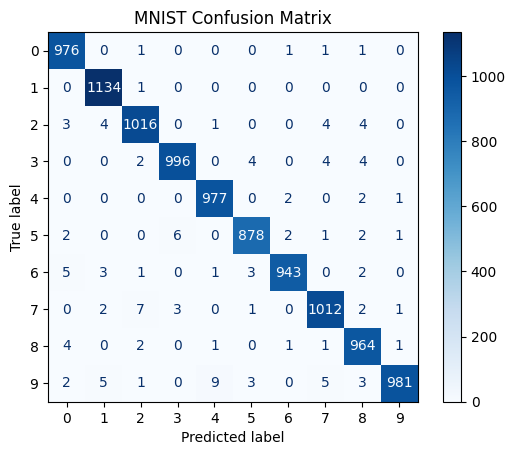

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# توقعات النموذج على صور الاختبار
probabilities = model.predict(x_test)
predicted_labels = np.argmax(probabilities, axis=1)

# تحويل التسميات الحقيقية من one-hot إلى أرقام
true_labels = np.argmax(y_test, axis=1)

# Precision, Recall, F1-score
print(classification_report(
    true_labels,
    predicted_labels,
    digits=3
))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels,
    cmap="Blues"
)

plt.title("MNIST Confusion Matrix")
plt.show()

## Success and Failure Cases

The model predictions are illustrated using one correctly classified digit and one incorrectly classified digit.

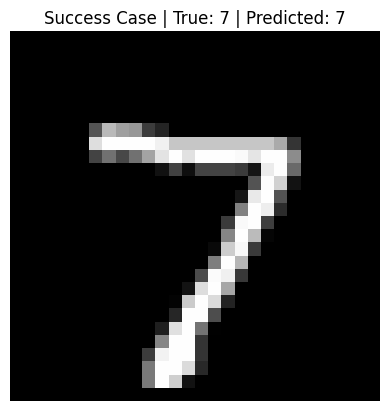

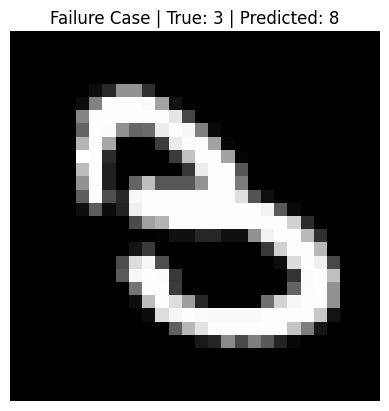

In [30]:
correct = np.where(predicted_labels == true_labels)[0]
incorrect = np.where(predicted_labels != true_labels)[0]

# مثال نجاح
i = correct[0]
plt.imshow(x_test[i].squeeze(), cmap="gray")
plt.title(
    f"Success Case | True: {true_labels[i]} | Predicted: {predicted_labels[i]}"
)
plt.axis("off")
plt.show()

# مثال فشل
i = incorrect[0]
plt.imshow(x_test[i].squeeze(), cmap="gray")
plt.title(
    f"Failure Case | True: {true_labels[i]} | Predicted: {predicted_labels[i]}"
)
plt.axis("off")
plt.show()

Save Model

In [31]:
model.save("mnist_cnn_model.keras")

## Single Image Prediction

The trained CNN model is used to predict a single image from the MNIST test dataset.

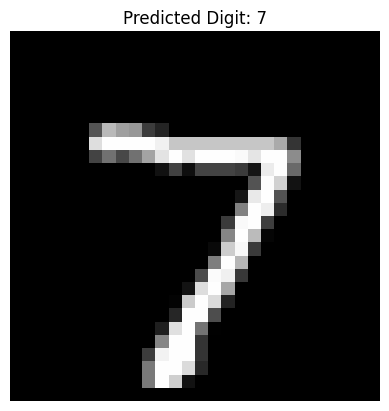

In [32]:
# Simple Digit Prediction Interface

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("mnist_cnn_model.keras")

# Select one image from the test dataset
index = 0
image = x_test[index]

# Make prediction
prediction = model.predict(image.reshape(1, 28, 28, 1), verbose=0)
predicted_digit = np.argmax(prediction)

# Display the image and prediction
plt.imshow(image.reshape(28, 28), cmap="gray")
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis("off")
plt.show()

## Interactive Digit Recognition

The user can draw a handwritten digit using the interactive canvas and click Predict to receive the model's prediction.

In [33]:
import tkinter as tk
from PIL import Image, ImageDraw
import numpy as np
from google.colab import output
from IPython.display import display, HTML

# واجهة رسم الرقم
display(HTML("""
<canvas id="canvas" width="280" height="280"
style="border:2px solid black; background:black;"></canvas>
<br><br>
<button onclick="predictDigit()">Predict</button>
<button onclick="clearCanvas()">Clear</button>

<script>
var canvas = document.getElementById("canvas");
var ctx = canvas.getContext("2d");

ctx.fillStyle = "black";
ctx.fillRect(0,0,280,280);

ctx.strokeStyle = "white";
ctx.lineWidth = 20;
ctx.lineCap = "round";

var drawing = false;

canvas.onmousedown = function(e) {
    drawing = true;
    ctx.beginPath();
    ctx.moveTo(e.offsetX, e.offsetY);
};

canvas.onmousemove = function(e) {
    if (!drawing) return;
    ctx.lineTo(e.offsetX, e.offsetY);
    ctx.stroke();
};

canvas.onmouseup = function() {
    drawing = false;
};

function clearCanvas() {
    ctx.fillStyle = "black";
    ctx.fillRect(0,0,280,280);
}

async function predictDigit() {
    var data = canvas.toDataURL("image/png");
    google.colab.kernel.invokeFunction(
        'notebook.predict_digit',
        [data],
        {}
    );
}
</script>
"""))

## Prediction Processing

The drawn image is converted into a format compatible with the MNIST dataset before being passed to the CNN model for prediction. The system displays the predicted digit along with the model's confidence score..

In [34]:
import base64
import io
from PIL import Image
import numpy as np
from IPython.display import display
from google.colab import output

def predict_digit(data):
    # تحويل الصورة من Base64 إلى صورة
    data = data.split(",")[1]
    image = Image.open(io.BytesIO(base64.b64decode(data))).convert("L")

    # تحويل الصورة إلى NumPy
    img = np.array(image)

    # تحديد مكان الرقم الأبيض
    coords = np.argwhere(img > 30)

    if coords.size == 0:
        print("Please draw a digit first.")
        return

    # قص الرقم فقط
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    digit = img[y_min:y_max+1, x_min:x_max+1]

    # جعل الرقم مربعًا
    h, w = digit.shape
    size = max(h, w)

    square = np.zeros((size, size), dtype=np.uint8)

    y_offset = (size - h) // 2
    x_offset = (size - w) // 2

    square[y_offset:y_offset+h, x_offset:x_offset+w] = digit

    # تصغير إلى 28×28 مثل MNIST
    digit = Image.fromarray(square).resize((28, 28))

    # تجهيز الصورة للنموذج
    digit = np.array(digit).astype("float32") / 255.0
    digit = digit.reshape(1, 28, 28, 1)

    # التنبؤ
    prediction = model.predict(digit, verbose=0)

    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    print("Predicted Digit:", predicted_digit)
    print(f"Confidence: {confidence:.2f}%")

output.register_callback("notebook.predict_digit", predict_digit)

## How to Run the Project

1. Open the notebook in Google Colab.
2. Run the cells from top to bottom.
3. The model will be trained and evaluated on the MNIST dataset.
4. Use the Interactive Digit Recognition section to draw a handwritten digit.
5. Click Predict to get the model prediction.

## Workflow / System Diagram

**Input Image**  
↓  
**Preprocessing**  
Resize → Normalize → Reshape  
↓  
**CNN Model**  
Convolution → Max Pooling → Dense  
↓  
**Prediction**  
↓  
**Predicted Digit**

## Results

The CNN model achieved a test accuracy of approximately 98.64% on the MNIST test dataset.

The classification report shows Precision, Recall, and F1-score across all ten digit classes. The model was also evaluated using a Confusion Matrix to analyze its classification performance.

## Technologies Used

- Python
- TensorFlow / Keras
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab

## Future Improvements

The system could be further improved by:
- Allowing users to upload handwritten digit images.
- Improving the user interface.
- Testing the model with more diverse handwriting styles.
- Exploring additional CNN architectures.

## Relevant Chapters from Deep Learning with Python
- [Chapter 8: Image classification](https://deeplearningwithpython.io/chapters/chapter08_image-classification)
